In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family":       "serif",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

SEED         = 42
PARQUET_PATH = r"C:\Users\super\Desktop\Data Thesis\final_df_clustered.parquet"
BASELINE_PT  = r"C:\Users\super\Desktop\Data Thesis\BaselinesGrid\transformer_best.pt"
FAIR_PT      = r"C:\Users\super\Desktop\Data Thesis\BaselinesGrid\transformer_fair.pt"
BEST_PARAMS  = r"C:\Users\super\Desktop\Data Thesis\BaselinesGrid\transformer_best_params.json"
MAX_SEQ_LEN  = 80
BATCH_SIZE   = 32
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(SEED)
torch.manual_seed(SEED)

print("Loading data...")
final_df = pd.read_parquet(PARQUET_PATH)

gaze_cols = [c for c in final_df.columns if "gaze" in c]
pose_cols = [c for c in final_df.columns if "pose" in c]
au_r_cols = [c for c in final_df.columns if c.startswith("AU") and c.endswith("_r")]
au_c_cols = [c for c in final_df.columns if c.startswith("AU") and c.endswith("_c")]
FEATURE_COLS = au_r_cols + au_c_cols + gaze_cols + pose_cols
N_FEATURES   = len(FEATURE_COLS)

assert "behavioral_cluster" not in FEATURE_COLS
print(f"  Features: {N_FEATURES}  |  Participants: {final_df['participant_id'].nunique()}")

Loading data...
  Features: 49  |  Participants: 102


In [2]:
participant_label = (
    final_df.groupby("participant_id")["engagement"]
    .agg(lambda x: int(x.mean() >= 0.5))
)
engaged_participants    = participant_label[participant_label == 1].index.values.copy()
disengaged_participants = participant_label[participant_label == 0].index.values.copy()

rng = np.random.default_rng(SEED)
rng.shuffle(engaged_participants)
rng.shuffle(disengaged_participants)

def stratified_split(arr, train_frac=0.70, val_frac=0.15):
    n       = len(arr)
    n_train = int(n * train_frac)
    n_val   = int(n * val_frac)
    return arr[:n_train], arr[n_train:n_train + n_val], arr[n_train + n_val:]

train_eng, val_eng, test_eng = stratified_split(engaged_participants)
train_dis, val_dis, test_dis = stratified_split(disengaged_participants)

train_participants = np.concatenate([train_eng, train_dis])
val_participants   = np.concatenate([val_eng,   val_dis])
test_participants  = np.concatenate([test_eng,  test_dis])

train_mask = final_df["participant_id"].isin(train_participants)

clip_meta = (
    final_df.groupby("clip_id")
    .agg(
        engagement         = ("engagement",         "first"),
        participant_id     = ("participant_id",     "first"),
        behavioral_cluster = ("behavioral_cluster", "first")
    )
    .reset_index()
)

train_clips = clip_meta[clip_meta["participant_id"].isin(train_participants)].reset_index(drop=True)
val_clips   = clip_meta[clip_meta["participant_id"].isin(val_participants)].reset_index(drop=True)
test_clips  = clip_meta[clip_meta["participant_id"].isin(test_participants)].reset_index(drop=True)

scaler = StandardScaler()
scaler.fit(final_df.loc[train_mask, FEATURE_COLS])
final_df[FEATURE_COLS] = scaler.transform(final_df[FEATURE_COLS])

print(f"Clips — train: {len(train_clips):,}  val: {len(val_clips):,}  test: {len(test_clips):,}")

Clips — train: 8,484  val: 1,832  test: 1,777


Subgroup sample distribution across splits:
     Split   Cluster  Participants  Clips  Engaged clips  Disengaged clips  % Engaged
     Train Cluster 0            22   2172           1738               434       80.0
     Train Cluster 1            49   6312           5125              1187       81.2
Validation Cluster 0             7    824            586               238       71.1
Validation Cluster 1             7   1008            840               168       83.3
      Test Cluster 0             6    516            393               123       76.2
      Test Cluster 1            11   1261           1028               233       81.5


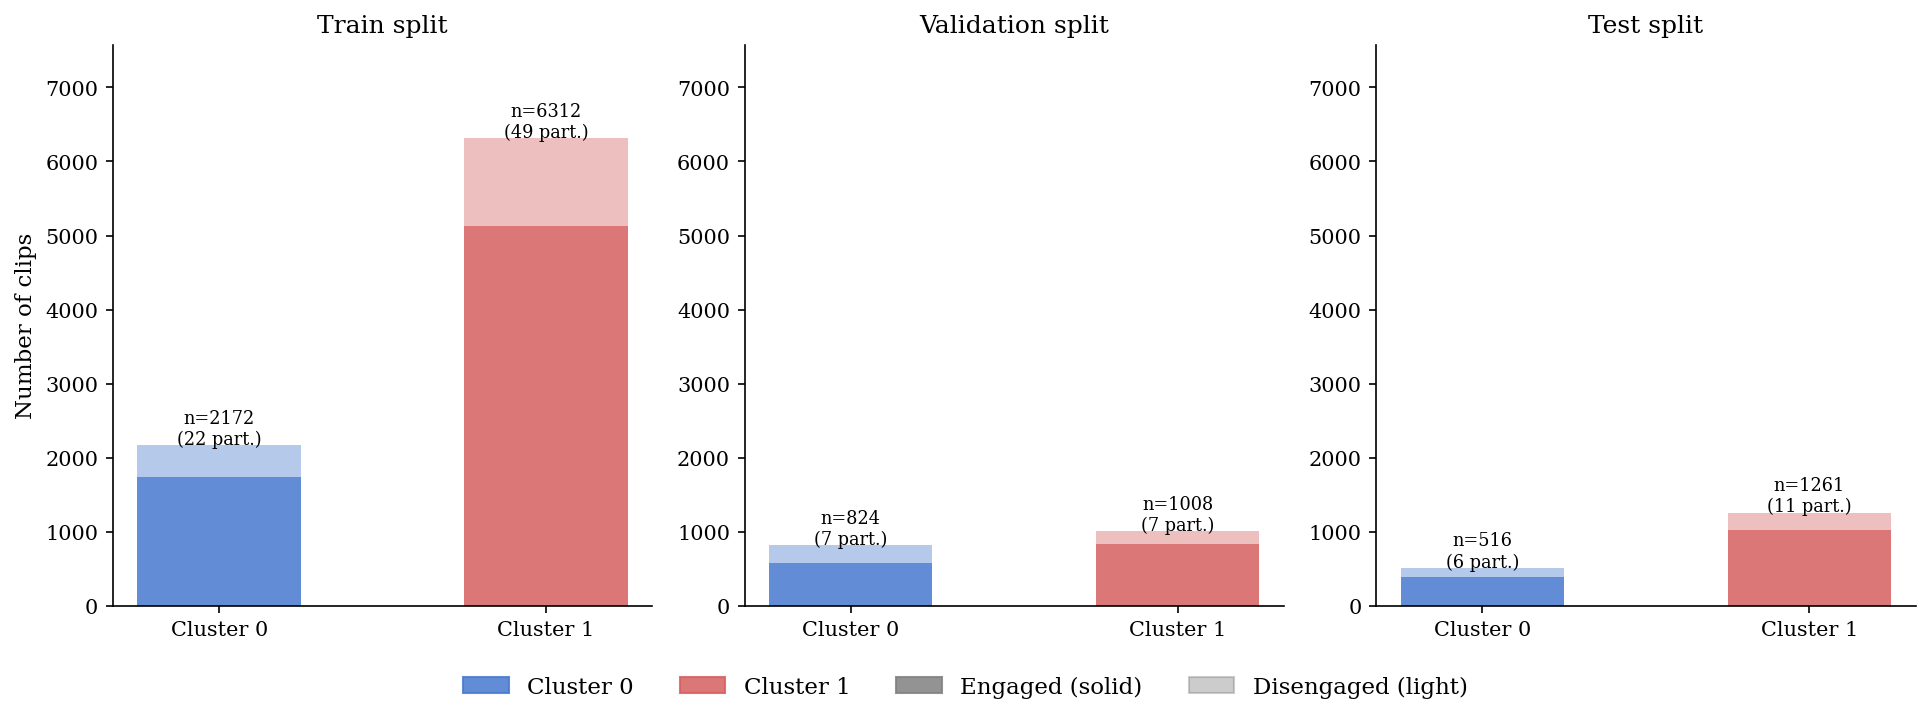

Saved: fig_split_distribution.pdf/.png


In [4]:
splits = {
    "Train": train_clips,
    "Validation": val_clips,
    "Test": test_clips
}

rows = []
for split_name, clips_df in splits.items():
    for cluster in [0, 1]:
        subset = clips_df[clips_df["behavioral_cluster"] == cluster]
        n_clips = len(subset)
        n_participants = subset["participant_id"].nunique()
        n_engaged    = (subset["engagement"] == 1).sum()
        n_disengaged = (subset["engagement"] == 0).sum()
        pct_engaged  = n_engaged / n_clips * 100
        rows.append({
            "Split":          split_name,
            "Cluster":        f"Cluster {cluster}",
            "Participants":   n_participants,
            "Clips":          n_clips,
            "Engaged clips":  n_engaged,
            "Disengaged clips": n_disengaged,
            "% Engaged":      round(pct_engaged, 1)
        })

dist_df = pd.DataFrame(rows)
print("Subgroup sample distribution across splits:")
print(dist_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)

split_names  = ["Train", "Validation", "Test"]
cluster_colors = {0: "#4878CF", 1: "#D65F5F"}
bar_width    = 0.35

for ax, split_name in zip(axes, split_names):
    subset = dist_df[dist_df["Split"] == split_name]
    x      = np.arange(2)   # two clusters

    for ci, cluster in enumerate([0, 1]):
        row        = subset[subset["Cluster"] == f"Cluster {cluster}"].iloc[0]
        engaged    = row["Engaged clips"]
        disengaged = row["Disengaged clips"]
        ax.bar(ci, engaged,    bottom=0,        width=bar_width + 0.15,
               color=cluster_colors[ci], alpha=0.85, label="Engaged" if ci == 0 else "")
        ax.bar(ci, disengaged, bottom=engaged,  width=bar_width + 0.15,
               color=cluster_colors[ci], alpha=0.40, label="Disengaged" if ci == 0 else "")
        ax.text(ci, engaged + disengaged + 15,
                f"n={row['Clips']}\n({row['Participants']} part.)",
                ha="center", fontsize=8.5)

    ax.set_title(f"{split_name} split")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Cluster 0", "Cluster 1"])
    ax.set_ylabel("Number of clips" if ax == axes[0] else "")
    ax.set_ylim(0, max(dist_df["Clips"]) * 1.2)

# Legend
legend_handles = [
    mpatches.Patch(color="#4878CF", alpha=0.85, label="Cluster 0"),
    mpatches.Patch(color="#D65F5F", alpha=0.85, label="Cluster 1"),
    mpatches.Patch(color="grey",    alpha=0.85, label="Engaged (solid)"),
    mpatches.Patch(color="grey",    alpha=0.40, label="Disengaged (light)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=4,
           frameon=False, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig("fig_split_distribution.pdf", bbox_inches="tight")
plt.savefig("fig_split_distribution.png", bbox_inches="tight")
plt.show()
print("Saved: fig_split_distribution.pdf/.png")

In [5]:
import json

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=MAX_SEQ_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe           = torch.zeros(max_len, d_model)
        position     = torch.arange(0, max_len).unsqueeze(1).float()
        div_term     = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1, n_classes=2,
                 max_len=MAX_SEQ_LEN):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_enc    = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x, return_representations=False):
        x      = self.pos_enc(self.input_proj(x))
        x      = self.encoder(x)
        rep    = self.dropout(x.mean(dim=1))
        logits = self.classifier(rep)
        if return_representations:
            return logits, rep
        return logits


class EngagementDataset(Dataset):
    def __init__(self, clips_df, full_df, max_len=MAX_SEQ_LEN):
        self.max_len  = max_len
        self.clip_ids = clips_df["clip_id"].tolist()
        self.labels   = clips_df["engagement"].tolist()
        self.clusters = clips_df["behavioral_cluster"].tolist()
        relevant      = full_df[full_df["clip_id"].isin(self.clip_ids)]
        self.clip_dict = {
            cid: grp.sort_values("timestep")[FEATURE_COLS].values.astype(np.float32)
            for cid, grp in relevant.groupby("clip_id")
        }

    def __len__(self):
        return len(self.clip_ids)

    def __getitem__(self, idx):
        seq = self.clip_dict.get(
            self.clip_ids[idx],
            np.zeros((1, N_FEATURES), dtype=np.float32)
        )
        T = seq.shape[0]
        if T >= self.max_len:
            seq = seq[:self.max_len]
        else:
            seq = np.vstack([seq, np.zeros((self.max_len - T, N_FEATURES),
                                           dtype=np.float32)])
        return (torch.tensor(seq),
                torch.tensor(self.labels[idx],   dtype=torch.long),
                torch.tensor(self.clusters[idx], dtype=torch.long))


def load_model(checkpoint_path):
    with open(BEST_PARAMS) as f:
        params = json.load(f)
    model = TransformerClassifier(
        input_dim       = N_FEATURES,
        d_model         = int(params["d_model"]),
        nhead           = int(params["nhead"]),
        num_layers      = int(params["num_layers"]),
        dim_feedforward = int(params["dim_feedforward"]),
        dropout         = params["dropout"]
    ).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()
    return model


def run_inference(model, loader):
    preds, labels, clusters = [], [], []
    with torch.no_grad():
        for X_batch, y_batch, c_batch in loader:
            preds.extend(model(X_batch.to(DEVICE)).argmax(dim=1).cpu().numpy())
            labels.extend(y_batch.numpy())
            clusters.extend(c_batch.numpy())
    return np.array(labels), np.array(preds), np.array(clusters)


print("Building test dataset and loading models...")
test_dataset  = EngagementDataset(test_clips, final_df)
test_loader   = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=0)

baseline_model = load_model(BASELINE_PT)
fair_model     = load_model(FAIR_PT)

y_true_b, y_pred_b, clusters_b = run_inference(baseline_model, test_loader)
y_true_f, y_pred_f, clusters_f = run_inference(fair_model,     test_loader)

cluster_ids = test_clips["behavioral_cluster"].values.astype(int)
print("Inference complete.")

Building test dataset and loading models...
Inference complete.


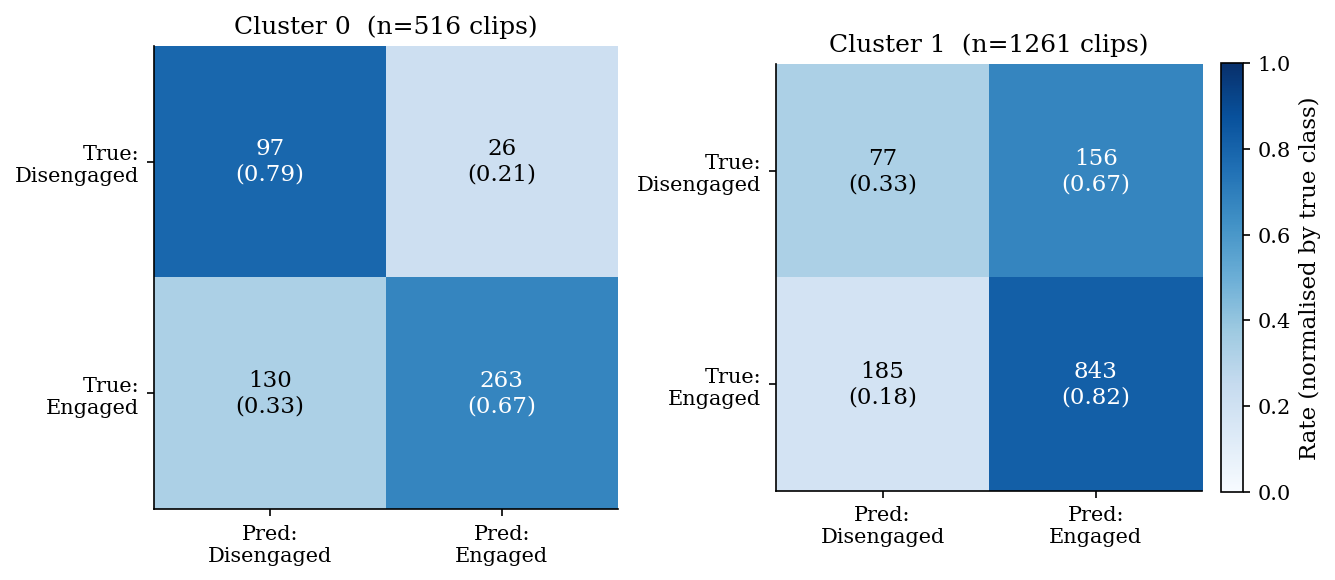

Saved: fig_cm_baseline.pdf/.png


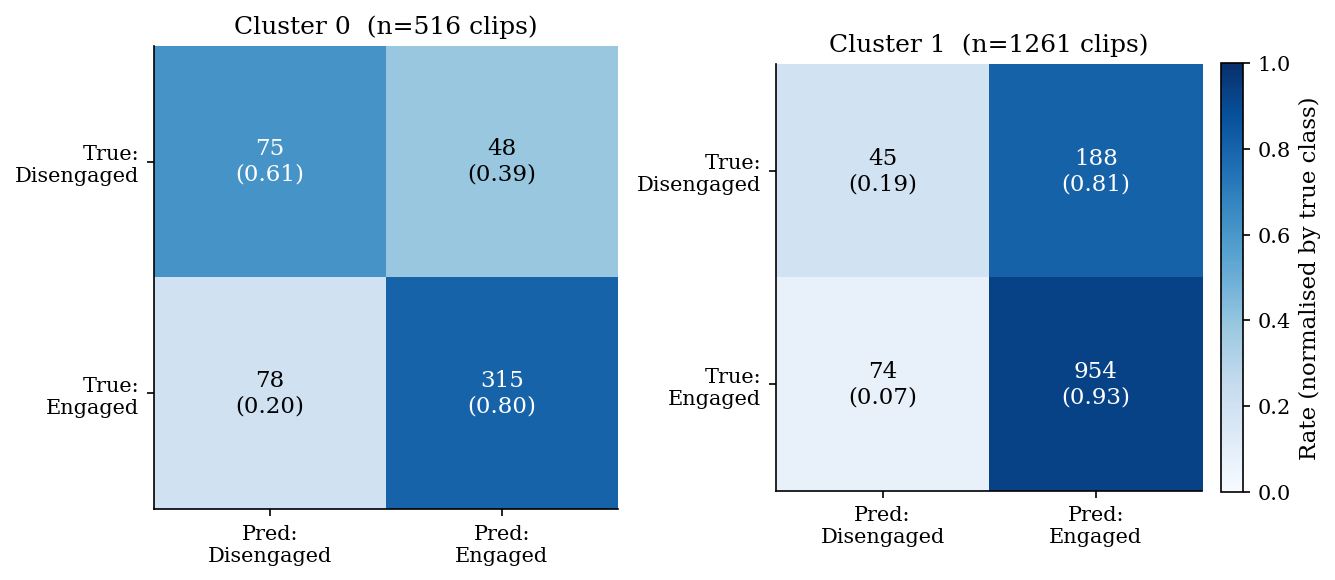

Saved: fig_cm_fair.pdf/.png


In [6]:
def plot_confusion_matrices(y_true, y_pred, cluster_ids, model_name, filename):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    class_names = ["Disengaged", "Engaged"]

    for ci, cluster in enumerate([0, 1]):
        ax   = axes[ci]
        mask = cluster_ids == cluster
        yt   = y_true[mask]
        yp   = y_pred[mask]
        n    = len(yt)

        # Build 2×2 confusion matrix manually
        cm = np.zeros((2, 2), dtype=int)
        for true, pred in zip(yt, yp):
            cm[true][pred] += 1

        # Normalise by true class (rows sum to 1) for readability
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

        # Annotate cells with count and normalised rate
        for i in range(2):
            for j in range(2):
                ax.text(j, i,
                        f"{cm[i,j]}\n({cm_norm[i,j]:.2f})",
                        ha="center", va="center", fontsize=11,
                        color="white" if cm_norm[i,j] > 0.5 else "black")

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels([f"Pred:\n{c}" for c in class_names])
        ax.set_yticklabels([f"True:\n{c}" for c in class_names])
        ax.set_title(f"Cluster {cluster}  (n={n} clips)")

    plt.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04,
                 label="Rate (normalised by true class)")

    plt.tight_layout()
    plt.savefig(f"{filename}.pdf", bbox_inches="tight")
    plt.savefig(f"{filename}.png", bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}.pdf/.png")


plot_confusion_matrices(y_true_b, y_pred_b, cluster_ids,
                        "Baseline Transformer",
                        "fig_cm_baseline")

plot_confusion_matrices(y_true_f, y_pred_f, cluster_ids,
                        "Fair Transformer",
                        "fig_cm_fair")

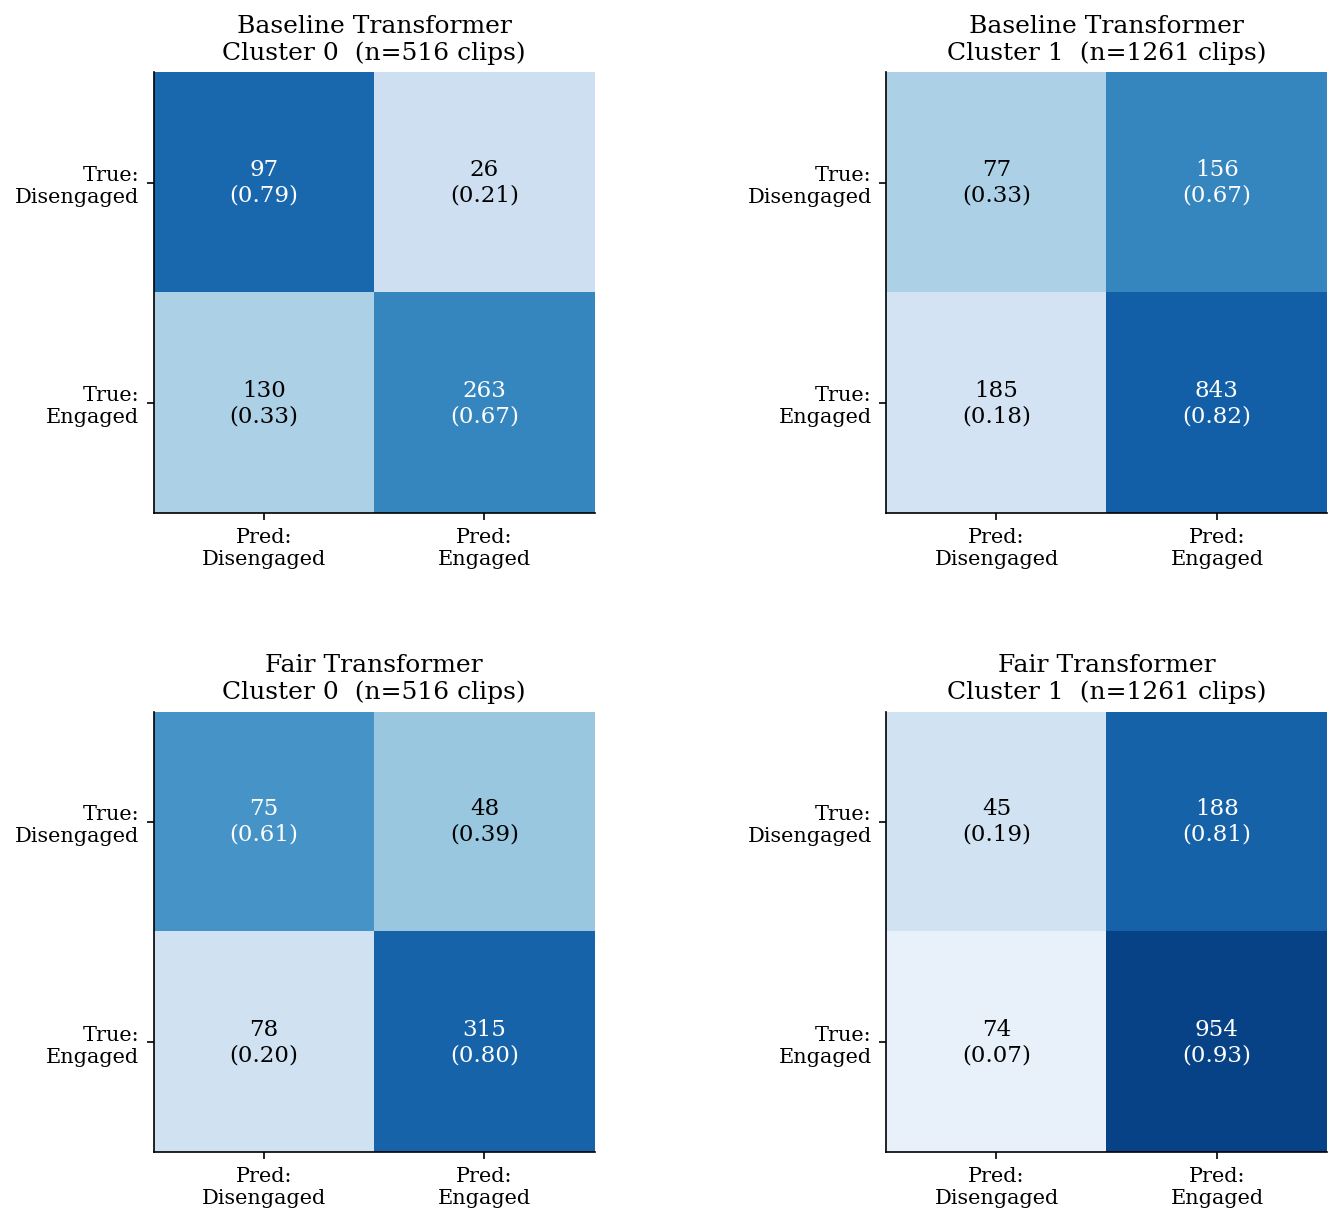

Saved: fig_cm_comparison.pdf/.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))  # slightly taller
class_names = ["Disengaged", "Engaged"]
model_data  = [
    (y_true_b, y_pred_b, cluster_ids, "Baseline Transformer"),
    (y_true_f, y_pred_f, cluster_ids, "Fair Transformer"),
]

for row_idx, (yt_all, yp_all, cids, model_name) in enumerate(model_data):
    for col_idx, cluster in enumerate([0, 1]):
        ax   = axes[row_idx][col_idx]
        mask = cids == cluster
        yt   = yt_all[mask]
        yp   = yp_all[mask]
        n    = len(yt)

        cm      = np.zeros((2, 2), dtype=int)
        for true, pred in zip(yt, yp):
            cm[true][pred] += 1
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

        for i in range(2):
            for j in range(2):
                ax.text(j, i,
                        f"{cm[i,j]}\n({cm_norm[i,j]:.2f})",
                        ha="center", va="center", fontsize=11,
                        color="white" if cm_norm[i,j] > 0.5 else "black")

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels([f"Pred:\n{c}" for c in class_names])
        ax.set_yticklabels([f"True:\n{c}" for c in class_names])
        ax.set_title(f"{model_name}\nCluster {cluster}  (n={n} clips)")

plt.subplots_adjust(left=0.1, right=0.95, top=0.88, bottom=0.08,
                    hspace=0.45, wspace=0.35)
plt.savefig("fig_cm_comparison.pdf", bbox_inches="tight")
plt.savefig("fig_cm_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: fig_cm_comparison.pdf/.png")